# **Práctica 2 - Funciones básicas de OpenCV**

En esta práctica se trabajan distintas funciones básicas de procesamiento de imágenes mediante OpenCV. Se utilizarán operaciones como la conversión entre espacios de color, detección de bordes, umbralizado, histogramas y operaciones sobre imágenes y vídeo.

Para comenzar se importan OpenCV, NumPy y Matplotlib, que se utilizarán para el procesamiento, manejo y visualización de las imágenes.

In [11]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

Se carga la imagen del mandril `mandril.jpg` mediante `cv2.imread()`. OpenCV almacena las imágenes en formato BGR, aunque para las primeras operaciones se trabajará directamente con una versión en escala de grises obtenida mediante `cv2.cvtColor()`.

A partir de la imagen en escala de grises se aplica el detector de bordes Canny mediante `cv2.Canny()`. El resultado es una imagen cuyos píxeles toman valores 0 o 255, representando en blanco los bordes detectados.


In [12]:
img = cv2.imread('mandril.jpg')
if img is None:
    raise FileNotFoundError('mandril.jpg')

gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)


**TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.**

Para realizar el conteo por filas se utiliza `cv2.reduce()`, sumando los valores de los píxeles de cada una. A partir de estas sumas se obtiene `maxfil` y se seleccionan las filas cuyo valor es mayor o igual al 90 % del máximo.

Como los píxeles blancos de Canny tienen valor 255, se divide entre este valor para obtener el número de píxeles blancos. También se normaliza el resultado respecto al ancho de la imagen para representar la proporción de píxeles blancos de cada fila.

Finalmente, las filas seleccionadas se resaltan mediante líneas horizontales sobre una copia de la imagen de Canny.

Valor máximo de píxeles blancos en una fila: [220.]
Posiciones de las filas con >= 90% de maxfil: [6, 12, 15, 20, 21, 88, 100]
Número de filas que cumplen la condición: 7


(0.0, 512.0)

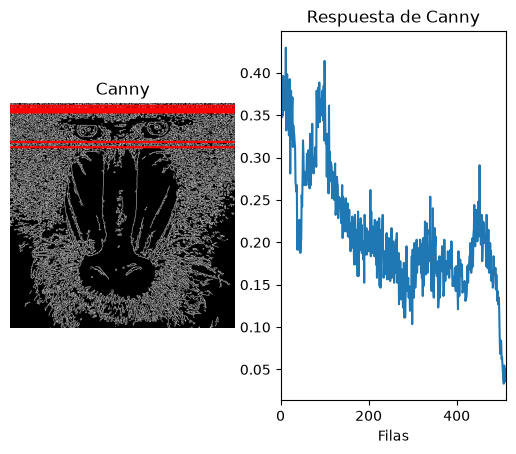

In [13]:
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)
#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
maxfil = max(row_counts)
rows2 = []
for i in range(len(row_counts)):
    if row_counts[i] >= maxfil * 0.90:
        rows2.append(i)
    
print("Valor máximo de píxeles blancos en una fila:", maxfil / 255)
print("Posiciones de las filas con >= 90% de maxfil:", rows2)
print("Número de filas que cumplen la condición:", len(rows2))


rows = row_counts[:, 0] / (255 * canny.shape[1])
cannyLineas = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)

for fila in rows2:
    cv2.line(cannyLineas, (0, fila), (canny.shape[1]-1, fila), (0,0,255), 3)


plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(cv2.cvtColor(cannyLineas, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)
#Rango en x definido por las columnas
plt.xlim([0, canny.shape[0]])

Como resultado se obtiene un máximo de 220 píxeles blancos en una misma fila (`maxfil`). A partir de este valor se seleccionan las filas que contienen al menos el 90 % de esa cantidad, obteniendo un total de 7 filas.

Las posiciones mostradas indican el número de cada una de las filas que cumple la condición. Estas filas se resaltan mediante líneas rojas sobre la imagen de Canny, permitiendo localizar visualmente las zonas con una mayor cantidad de píxeles blancos y, por tanto, una mayor presencia de bordes detectados.

En la gráfica se representa la proporción de píxeles blancos para cada fila de la imagen. Los valores más altos corresponden a las filas donde Canny ha detectado una mayor cantidad de píxeles pertenecientes a bordes, coincidiendo con las filas resaltadas en rojo en la imagen.

FIN TAREA 1!!!!!

Canny es el detector de bordes más destacado antes de los modelos de aprendizaje profundo. Un detector más simple es Sobel (realmente suele usarse como primer paso de Canny).
El operador de Sobel considera que cuando hay un borde, el valor de intensidad de los píxeles cercanos cambia de forma notable, calcular las derivadas proporciona una evidencia de dicho cambio. El operador de Sobel aproxima el cálculo de la derivada aplicando un kernel de tamaño impar basado en el patrón [1 2 1].

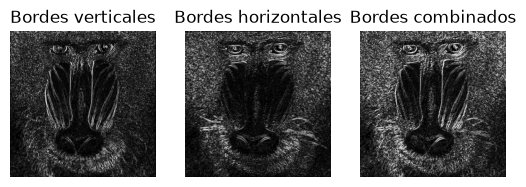

In [14]:
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

#Muestra ambos resultados
plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('Bordes verticales')
#Verticales
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobelx), cmap='gray') 
#plt.imshow(sobelx, cmap='gray') #Prueba sin convertir escala

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('Bordes horizontales')
#Horizontales
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobely), cmap='gray') 
#plt.imshow(sobelx, cmap='gray') #Prueba sin convertir escala

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Bordes combinados')
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobel), cmap='gray') 
#plt.imshow(sobel, cmap='gray') #Prueba sin convertir escala
plt.show()

Observa que visualizar la imagen resultado de Sobel directamente como escala de grises produce un resultado diferente. Ha sido necesario convertir a datos de tipo byte. La siguiente celda muestra dos variantes de conversión, con OpenCV y numpy, evidenciando alguna diferencia, además de los valores antes y tras escalar a 8 bits

Tipo de datos, valor mínimo y máximo en sobel: float64, -594.0, 570.0
Tipo de datos, valor mínimo y máximo en sobel8: uint8, 0, 255
Tipo de datos, valor mínimo y máximo en sobel8np: uint8, 0, 254


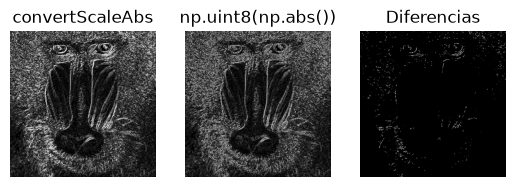

In [15]:
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel: {sobel.dtype}, {np.min(sobel)}, {np.max(sobel)}")

# Conversión a byte con openCV
sobel8 = cv2.convertScaleAbs(sobel)
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel8: {sobel8.dtype}, {np.min(sobel8)}, {np.max(sobel8)}")

# Conversión a byte con numpy
sobel8np = np.uint8(np.abs(sobel))
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel8np: {sobel8np.dtype}, {np.min(sobel8np)}, {np.max(sobel8np)}")

plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('convertScaleAbs')
plt.imshow(sobel8, cmap='gray') 

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('np.uint8(np.abs())')
plt.imshow(sobel8np, cmap='gray') 

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Diferencias')
plt.imshow(cv2.absdiff(sobel8,sobel8np), cmap='gray') 

plt.show()

Umbralizado de una imagen

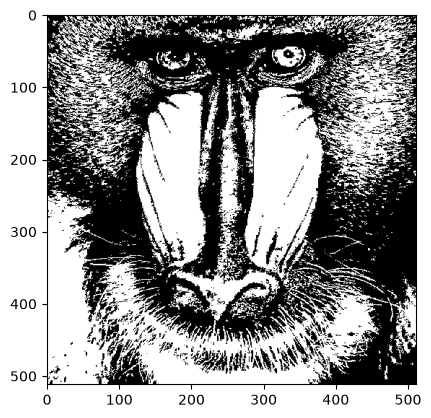

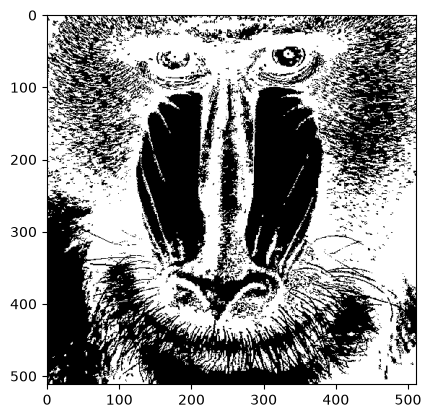

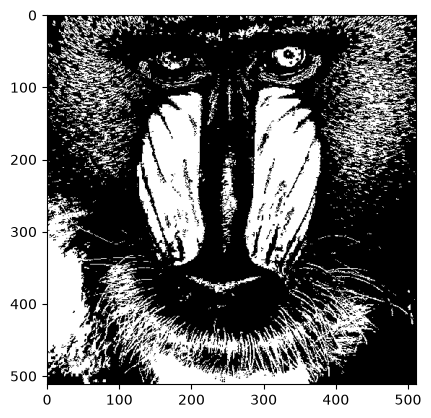

In [16]:
#Define valor umbral
valorUmbral = 130 #Prueba otros valores
#Obtiene imagen umbralizada para dicho valor definido
_, imagenUmbralizada = cv2.threshold(gris, valorUmbral, 255, cv2.THRESH_BINARY)
#Muestra resultado
plt.imshow(imagenUmbralizada, cmap='gray')
plt.show()

#El umbralizado inverso, los valores menores que el umbral se muestran en blanco
_, imagenUmbralizada = cv2.threshold(gris, valorUmbral, 255, cv2.THRESH_BINARY_INV)
#Muestra resultado
plt.imshow(imagenUmbralizada, cmap='gray')
plt.show()

#Valores en rango determinado por dos umbrales
imagenEnRango = cv2.inRange(gris, 150, 200)
#Muestra resultado
plt.imshow(imagenEnRango, cmap='gray')
plt.show()

El histograma de una imagen aporta información sobre el valor de umbral a elegir para ciertas situaciones

(0.0, 256.0)

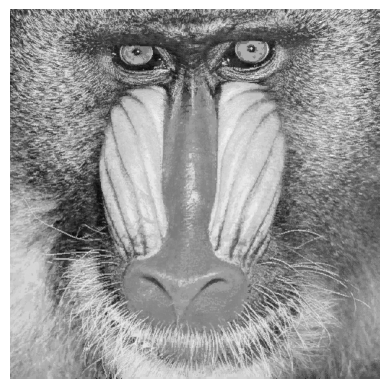

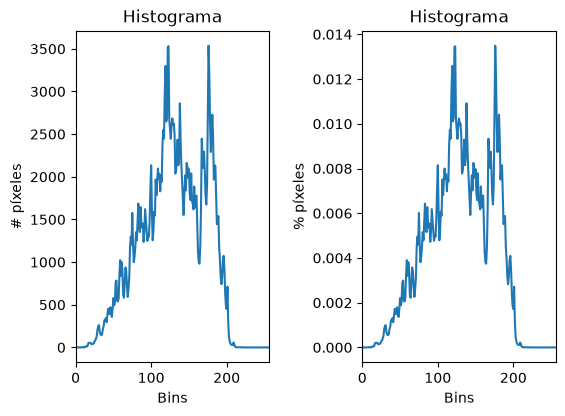

In [17]:
#Cálculo del histograma de una imagen en escala de grises
hist = cv2.calcHist([gris], [0], None, [256], [0, 256])

plt.figure()
plt.axis("off")
plt.imshow(gris, cmap='gray')

# Histograma sin normalizar
plt.figure()
plt.subplot(1, 2, 1)
plt.title("Histograma")
plt.xlabel("Bins")
plt.ylabel("# píxeles")
plt.plot(hist)
plt.xlim([0, 256])

#Normaliza el histograma en base al número de píxeles y lo muestra
hist /= hist.sum()

plt.subplot(1, 2, 2)
plt.title("Histograma")
plt.xlabel("Bins")
plt.ylabel("% píxeles")
plt.tight_layout(pad=3.0) #separación entre plots
plt.plot(hist)
plt.xlim([0, 256])

**TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?**

Máximo de píxeles por fila: 216
Máximo de píxeles por columna: 219
Filas por encima del 90 % del máximo:
[  2   3   4   5   8  11  12  19  20  24  51  80  81  82  83  84  85  87
 100]
Columnas por encima del 90 % del máximo:
[104 105 127 288]


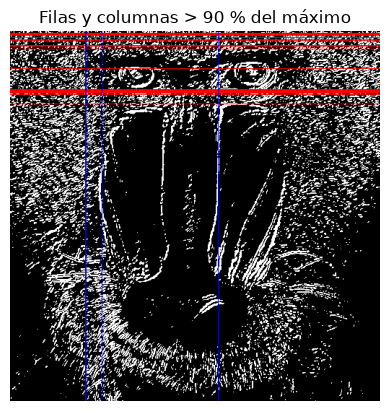

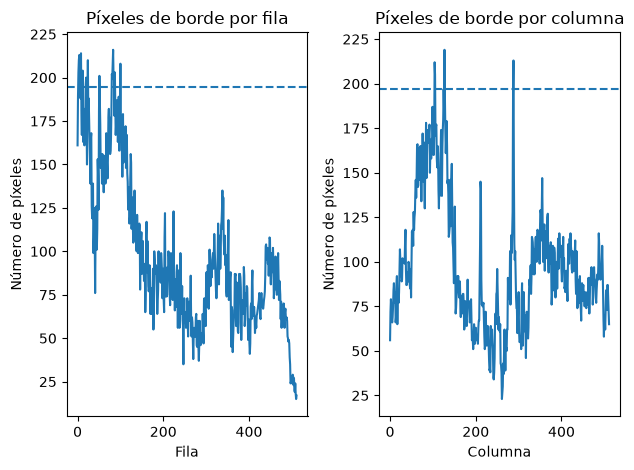

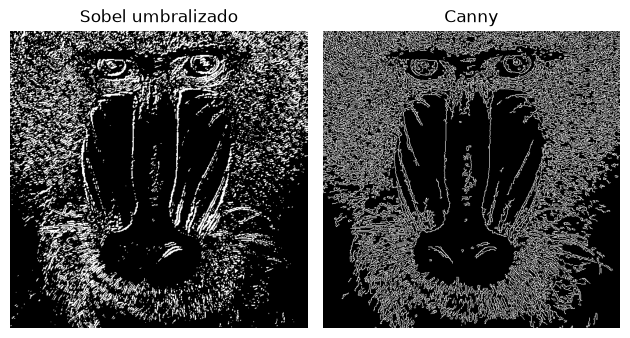

In [18]:
valorUmbralSobel = 100

_, sobelUmbralizado = cv2.threshold(sobel8, valorUmbralSobel, 255, cv2.THRESH_BINARY)

cuentaFilas = np.count_nonzero(sobelUmbralizado, axis=1)
cuentaColumnas = np.count_nonzero(sobelUmbralizado, axis=0)

maxFilas = np.max(cuentaFilas)
maxColumnas = np.max(cuentaColumnas)

print("Máximo de píxeles por fila:", maxFilas)
print("Máximo de píxeles por columna:", maxColumnas)

umbralFilas = 0.90 * maxFilas
umbralColumnas = 0.90 * maxColumnas

filasImportantes = np.where(cuentaFilas >= umbralFilas)[0]
columnasImportantes = np.where(cuentaColumnas >= umbralColumnas)[0]

print("Filas por encima del 90 % del máximo:")
print(filasImportantes)

print("Columnas por encima del 90 % del máximo:")
print(columnasImportantes)

mandrilMarcado = cv2.cvtColor(sobelUmbralizado, cv2.COLOR_GRAY2BGR)

for row in filasImportantes:
    cv2.line(mandrilMarcado, (0, row), (mandrilMarcado.shape[1] - 1, row), (0, 0, 255), 1)

for col in columnasImportantes:
    cv2.line(mandrilMarcado, (col, 0), (col, mandrilMarcado.shape[0] - 1), (255, 0, 0), 1)

plt.figure()
plt.imshow(cv2.cvtColor(mandrilMarcado, cv2.COLOR_BGR2RGB))
plt.title("Filas y columnas > 90 % del máximo")
plt.axis("off")
plt.show()

plt.figure()

plt.subplot(1, 2, 1)
plt.plot(cuentaFilas)
plt.axhline(umbralFilas, linestyle="--")
plt.title("Píxeles de borde por fila")
plt.xlabel("Fila")
plt.ylabel("Número de píxeles")

plt.subplot(1, 2, 2)
plt.plot(cuentaColumnas)
plt.axhline(umbralColumnas, linestyle="--")
plt.title("Píxeles de borde por columna")
plt.xlabel("Columna")
plt.ylabel("Número de píxeles")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# COMPARACIÓN ENTRE SOBEL Y CANNY
# ---------------------------------------------------------

# Mostrar juntos los resultados de Sobel umbralizado y Canny

plt.figure()

plt.subplot(1, 2, 1)
plt.imshow(sobelUmbralizado, cmap='gray')
plt.title("Sobel umbralizado")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(canny, cmap='gray')
plt.title("Canny")
plt.axis("off")

plt.tight_layout()
plt.show()

Diferencia de imágenes

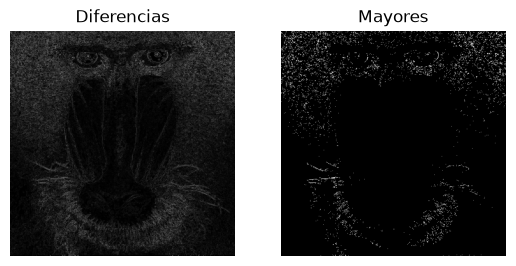

In [19]:
#Calcula la diferencia entre dos imágenes
#Utiliza la imagen original y la obtenida tras aplicar la gaussiana (creada en la celda dedicada a Sobel)
dif = cv2.absdiff(gris, ggris)

#Visualiza
plt.figure()
plt.subplot(1, 2, 1)
plt.title("Diferencias")
plt.axis("off")
plt.imshow(dif, cmap='gray') 

#Zonas de mayor diferencia tras aplicar umbral
res, imgdif = cv2.threshold(dif, 30, 255, cv2.THRESH_BINARY)
#Visualiza
plt.subplot(1, 2, 2)
plt.title("Mayores")
plt.axis("off")
plt.imshow(imgdif, cmap='gray') 
plt.show()


Webcam y sustracción de fotogramas

In [20]:
vid = cv2.VideoCapture(0)

#Marca de inicio
disponible = 0 
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        if disponible > 0:
            dif = cv2.absdiff(frame, pframe)        
            # Muestra resultado
            cv2.imshow('Diferencia', dif)    
        else:
            disponible = 1

        #Copia fotograma actual para la diferencia en el siguiente forograma
        pframe = frame.copy()
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

KeyboardInterrupt: 

Webcam y sustracción de modelo del fondo

In [ ]:
vid = cv2.VideoCapture(0)

# Fondo
# Inicializa la sustracción del fondo con mezcla de gaussianas y detección de sombras
eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50, detectShadows=True)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        # Aplica efecto espejo sobre la entrada
        framem=cv2.flip(frame, 1)
        
        #Con un segundo parámerto se puede definir máscara con zonas a actualizar
        objetos = eliminadorFondo.apply(framem)
        #objetos = eliminadorFondo.apply(framem, objetos, 0)  #No actualiza el fondo
        # Obtiene fondo
        background = eliminadorFondo.getBackgroundImage()

        # Muestra resultado
        cv2.imshow('Fotograma', objetos)
        # Muestra fondo
        cv2.imshow('Fondo', background)
  
   
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

**TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.**